# **Supply Chain Shipment Pricing**

# **1. Methodology**

The methodology used in the project iis CRISP-DM, for predictive analytics tasks.

## **1.1 Business Understanding**

### **About the data set**

This dataset provides supply chain health commodity shipment and pricing data. Specifically, the data set identifies Antiretroviral (ARV) and HIV lab shipments to supported countries. In addition, the data set provides the commodity pricing and associated supply chain expenses necessary to move the commodities to countries for use. The dataset has similar fields to the Global Fund's Price, Quality and Reporting (PQR) data. PEPFAR and the Global Fund represent the two largest procurers of HIV health commodities. This dataset, when analyzed in conjunction with the PQR data, provides a more complete picture of global spending on specific health commodities. The data are particularly valuable for understanding ranges and trends in pricing as well as volumes delivered by country. The US Government believes this data will help stakeholders make better, data-driven decisions. Care should be taken to consider contextual factors when using the database. Conclusions related to costs associated with moving specific line items or products to specific countries and lead times by product/country will not be accurate.

There are 33 variables in the data set, these are as follows:

* **id -** ID
* **project code -** Project code
* **pq # -** Price quote (PQ) number
* **po / so #**
* **asn/dn # -** Shipment number: Advanced Shipment Note (ASN) for Direct Drop deliveries, or Delivery Note (DN) for from RDC deliveries
* **country -** Destination country
* **managed by -** SCMS managing office: either the Program Management Office (PMO) in the U.S. or the relevant SCMS field office
* **fulfill via -** Method through which the shipment was fulfilled: via Direct Drop from vendor or from stock available in the RDCs
* **vendor inco term -** The vendor INCO term (also known as International Commercial Terms) for Direct Drop deliveries
* **shipment mode -** Method by which commodities are shipped
* **pq first sent to client date -** Date the PQ is first sent to the client
* **po sent to vendor date -** Date the PO is first sent to the vendor
* **scheduled delivery date -** Current anticipated delivery date
* **delivered to client date -** Date of delivery to client
* **delivery recorded date -** Date on which delivery to client was recorded in SCMS information systems
* **product group -** Product group for item, i.e. ARV, HRDT
* **sub classification -** Identifies relevant product sub classifications, such as whether ARVs are pediatric or adult, whether a malaria product is an artemisinin-based combination therapy (ACT), etc.
* **vendor -** Vendor name
* **item description -** Product name and formulation from Partnership for Supply Chain Management (PFSCM) Item Master
* **molecule/test type -** Active drug(s) or test kit type
* **brand -** Generic or branded name for the item
* **dosage -** Item dosage and unit
* **dosage form -** Dosage form for the item (tablet, oral solution, injection, etc.).
* **unit of measure (per pack) -** Pack quantity (pills or test kits) used to compute unit price
* **line item quantity -** Total quantity (packs) of commodity per line item
* **line item value -** Total value of commodity per line item
* **pack price -** Cost per pack (i.e. month s supply of ARVs, pack of 60 test kits)
* **unit price -** Cost per pill (for drugs) or per test (for test kits)
* **manufacturing site -** Identifies manufacturing site for the line item for direct drop and from RDC deliveries
* **first line designation -** Designates if the line in question shows the aggregated freight costs and weight associated with all items on the ASN DN
* **weight (kilograms) -** Weight for all lines on an ASN DN
* **freight cost (usd) -** Freight charges associated with all lines on the respective ASN DN
* **line item insurance (usd) -** Line item cost of insurance, created by applying an annual flat rate ( ) to commodity cost

### **Objectives**

* Develop a model to predict freight prices in USD.
* Analyze the impact of various features on the pricing of antiretroviral (ARV) supplies.
* Evaluate the performance of two machine learning models in forecasting costs in a high-dimensional structured dataset.
* Assess the interpretability of models in identifying the most influential factors driving freight pricing

## **1.2 Data Understanding**

## **a) Libraries**

In [121]:
#Data analysis and manipulation
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical features manipulation
from sklearn.preprocessing import LabelEncoder

# Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold

In [122]:
pd.set_option("display.max_columns", None)
supply = pd.read_csv("C:/Users/cmanu/OneDrive/Escritorio/NCIDA/DATAMINING/DM_Project/4-Supply_Chain_Shipment_Pricing_Dataset.csv")

In [123]:
supply.head()

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,pq first sent to client date,po sent to vendor date,scheduled delivery date,delivered to client date,delivery recorded date,product group,sub classification,vendor,item description,molecule/test type,brand,dosage,dosage form,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN


## **b) General and Statistical Analysis**

In [124]:
supply.describe()

,id,unit of measure (per pack),line item quantity,line item value,pack price,unit price,line item insurance (usd)
count,10324.00,10324.00,10324.00,10324.00,10324.00,10324.00,10037.00
mean,51098.97,77.99,18332.53,157650.57,21.91,0.61,240.12
std,31944.33,76.58,40035.30,345292.07,45.61,3.28,500.19
min,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,12795.75,30.00,408.00,4314.59,4.12,0.08,6.51
50%,57540.50,60.00,3000.00,30471.47,9.30,0.16,47.04
75%,83648.25,90.00,17039.75,166447.14,23.59,0.47,252.40
max,86823.00,1000.00,619999.00,5951990.40,1345.64,238.65,7708.44


In [125]:
supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

## **c) Unique and null values**

In [126]:
supply.nunique().sort_values()

fulfill via                         2
first line designation              2
managed by                          4
shipment mode                       4
product group                       5
sub classification                  6
vendor inco term                    8
dosage form                        17
unit of measure (per pack)         31
country                            43
brand                              48
dosage                             54
vendor                             73
molecule/test type                 86
manufacturing site                 88
project code                      142
unit price                        183
item description                  184
pq first sent to client date      765
po sent to vendor date            897
pack price                       1175
pq #                             1237
scheduled delivery date          2006
delivery recorded date           2042
delivered to client date         2093
weight (kilograms)               4688
line item qu

In [127]:
supply.isnull().sum().sort_values(ascending=False)

dosage                          1736
shipment mode                    360
line item insurance (usd)        287
molecule/test type                 0
brand                              0
dosage form                        0
unit of measure (per pack)         0
line item quantity                 0
line item value                    0
vendor                             0
pack price                         0
unit price                         0
manufacturing site                 0
first line designation             0
weight (kilograms)                 0
freight cost (usd)                 0
item description                   0
id                                 0
project code                       0
product group                      0
delivery recorded date             0
delivered to client date           0
scheduled delivery date            0
po sent to vendor date             0
pq first sent to client date       0
vendor inco term                   0
fulfill via                        0
m

In [128]:
(supply.isnull().sum().sort_values(ascending=False) / supply.shape[0])*100

dosage                         16.82
shipment mode                   3.49
line item insurance (usd)       2.78
molecule/test type              0.00
brand                           0.00
dosage form                     0.00
unit of measure (per pack)      0.00
line item quantity              0.00
line item value                 0.00
vendor                          0.00
pack price                      0.00
unit price                      0.00
manufacturing site              0.00
first line designation          0.00
weight (kilograms)              0.00
freight cost (usd)              0.00
item description                0.00
id                              0.00
project code                    0.00
product group                   0.00
delivery recorded date          0.00
delivered to client date        0.00
scheduled delivery date         0.00
po sent to vendor date          0.00
pq first sent to client date    0.00
vendor inco term                0.00
fulfill via                     0.00
m

## **d) Correlation between numerical variables**

Text(0.5, 1.0, 'Correlation Heatmap of Supply Chain')

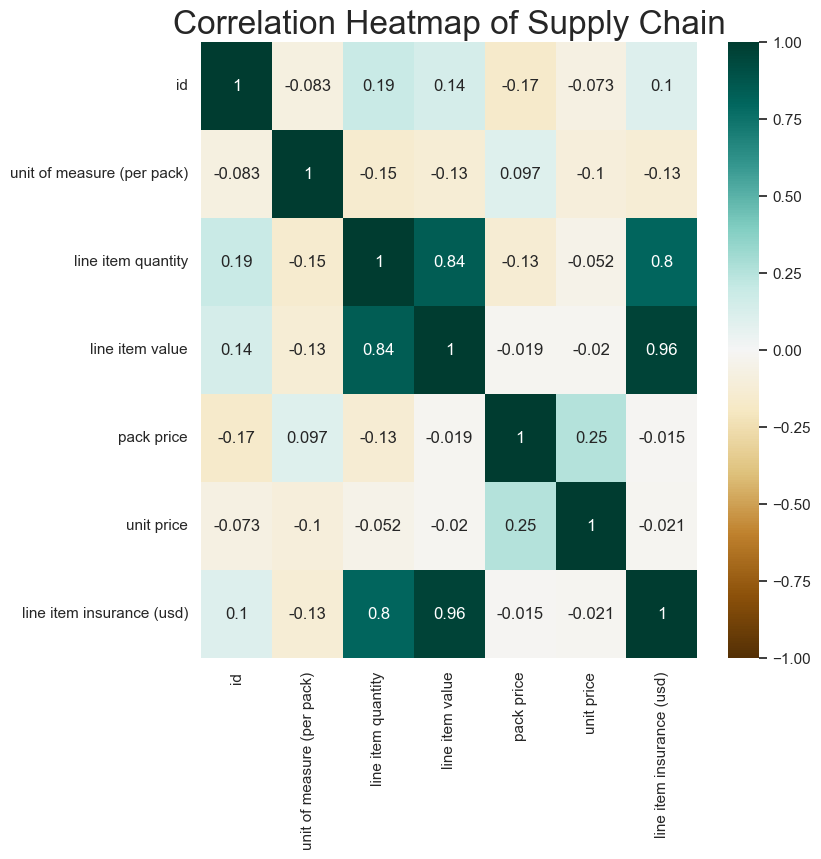

In [129]:
supply_nums = supply.select_dtypes(include=["number"])
plt.figure(figsize = (8, 8))
heatmap = sns.heatmap (supply_nums.corr(),vmin = -1, vmax = 1, annot = True,  cmap = "BrBG")
heatmap.set_title("Correlation Heatmap of Supply Chain", fontsize=24)

## **e) Distribution of Pack price**

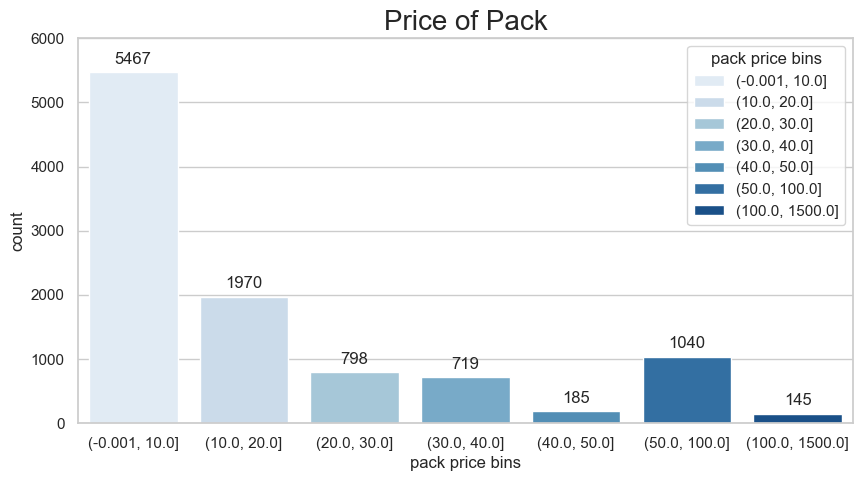

In [130]:
packprice_bins = [0, 10, 20, 30, 40, 50, 100, 1500]

supply ["pack price bins"] = pd.cut(supply["pack price"], bins=packprice_bins, include_lowest=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(x="pack price bins", data=supply, hue="pack price bins",palette= "Blues", dodge=False)
plt.title("Price of Pack", fontsize=20)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 6000)
plt.show()

## **e) Distribution of Line item insurance (USD)**

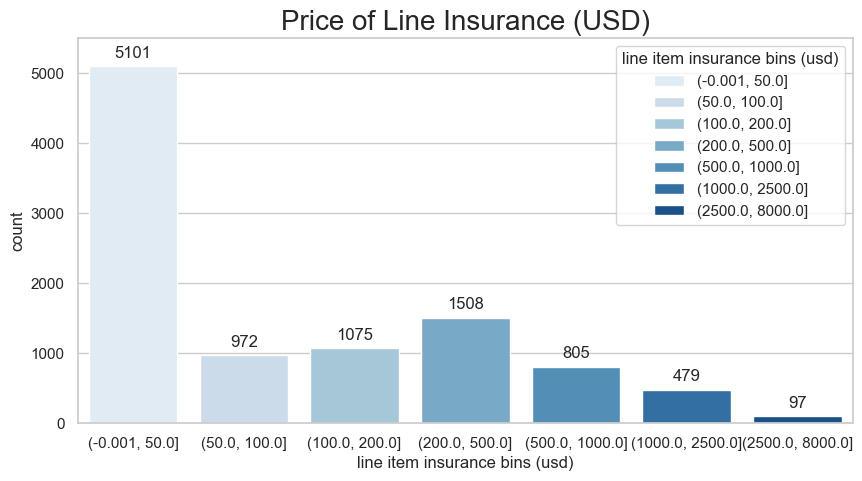

In [131]:
lineinsurance_bins = [0, 50, 100, 200, 500, 1000, 2500, 8000]

supply ["line item insurance bins (usd)"] = pd.cut(supply["line item insurance (usd)"], bins=lineinsurance_bins, include_lowest=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(x="line item insurance bins (usd)", data=supply, hue="line item insurance bins (usd)",palette= "Blues", dodge=False)
plt.title("Price of Line Insurance (USD)", fontsize=20)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 5500)
plt.show()

## **f) Frequency of Managed by**

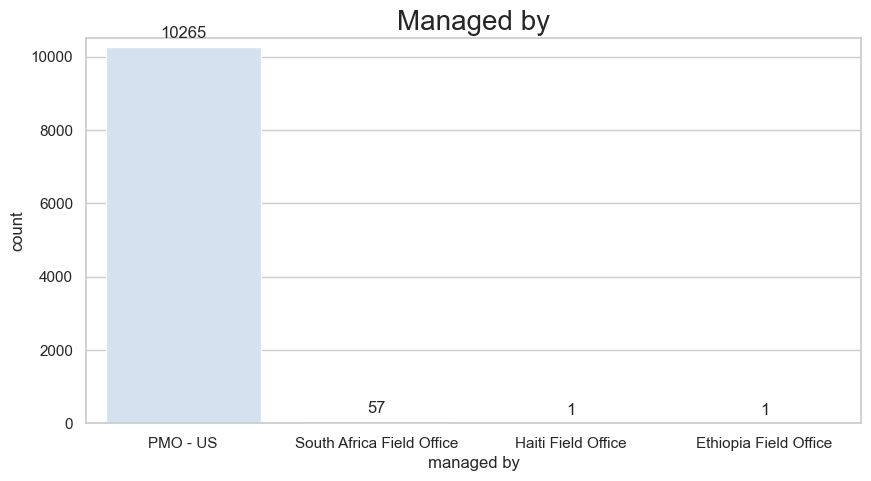

In [132]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(x=supply["managed by"], data=supply, hue=supply["managed by"],palette="Blues", dodge=False)
plt.title("Managed by", fontsize=20)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 10500)
plt.show()

## **g) Frequency of Shipment mode**

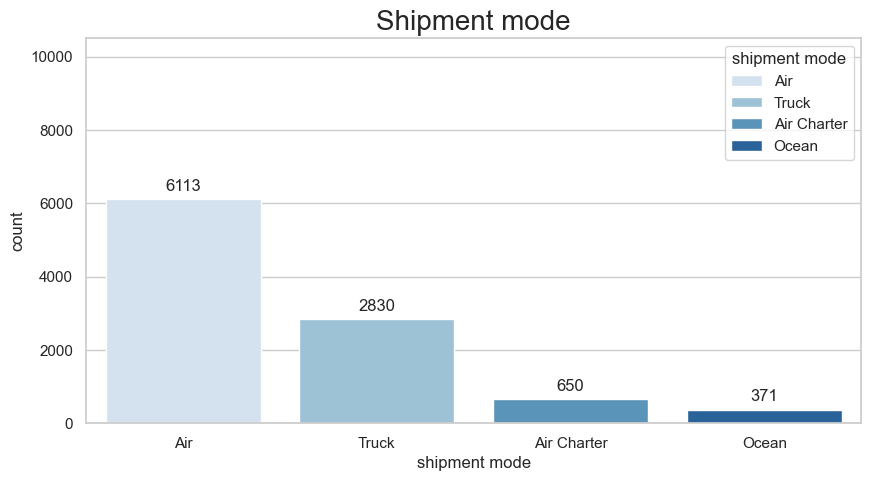

In [133]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(x=supply["shipment mode"], data=supply, hue=supply["shipment mode"],palette="Blues", dodge=False)
plt.title("Shipment mode", fontsize=20)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 10500)
plt.show()

## **h) Frequency of Product group**

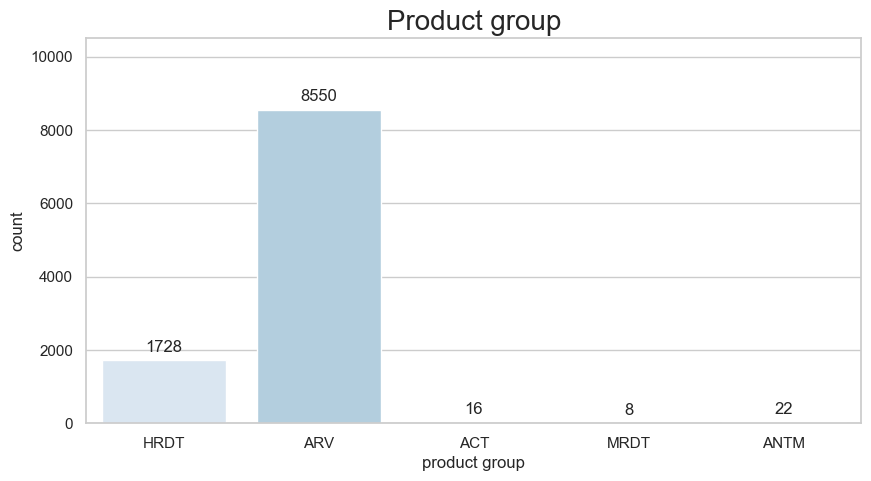

In [134]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.countplot(x=supply["product group"], data=supply, hue=supply["product group"],palette="Blues", dodge=False)
plt.title("Product group", fontsize=20)

for p in ax.containers:
    ax.bar_label(p, label_type="edge", fmt="%.0f", padding=4)
plt.ylim(0, 10500)
plt.show()

# **1.3 Data Preparation**

## **a) Handling missing values**

In [135]:
supply["shipment mode"] = supply["shipment mode"].fillna("Not specified")

print(supply["shipment mode"].value_counts(),"\n")

Air              6113
Truck            2830
Air Charter       650
Ocean             371
Not specified     360
Name: shipment mode, dtype: int64 



In [136]:
# Zero Freight cost could be included or exempt which is not useful for its calculation

supply = supply[supply["freight cost (usd)"] != 0]

## **b) Feature engineering**

### - **Dosage**

There are different dosages units of measure within the same dosage value. It must be separated as values of measure and unit of measure.

In [137]:
# Unit measure of each of the dosages
supply["dosage measure unit"] = supply["dosage"].str.findall(r"(mg|g|mg/ml|ml|g/ml)")

# If there is more than one measure, measure will be transformed into strings
for i in range(len(supply["dosage measure unit"])):
    if isinstance(supply["dosage measure unit"].iloc[i], list):
        supply.at[i, "dosage measure unit"] = ", ".join(supply["dosage measure unit"].iloc[i])


# It is necessary to extract the dosages values without the unit of measure and separate them into different columns if there is more than one.
split_columns = supply["dosage"].str.extractall(r"([\d.]+)").unstack()
split_columns.columns = [f"Dosage {i+1}" for i in range(len(split_columns.columns))]

# Join the new features to the Supply data set
supply = pd.concat([supply, split_columns], axis=1)
supply.head()

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,pq first sent to client date,po sent to vendor date,scheduled delivery date,delivered to client date,delivery recorded date,product group,sub classification,vendor,item description,molecule/test type,brand,dosage,dosage form,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd),pack price bins,line item insurance bins (usd),dosage measure unit,Dosage 1,Dosage 2,Dosage 3
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN,"(20.0, 30.0]",NaN,NaN,NaN,NaN,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN,"(-0.001, 10.0]",NaN,"mg, ml",10,NaN,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN,"(50.0, 100.0]",NaN,NaN,NaN,NaN,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN,"(-0.001, 10.0]",NaN,mg,150,NaN,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN,"(-0.001, 10.0]",NaN,mg,30,NaN,NaN


### - **Delivery date**

In [138]:
# All records must have a date to be processed.

supply = supply[~((supply["delivered to client date"] == "Pre-PQ Process") |
                  (supply["pq first sent to client date"] == "Pre-PQ Process"))]

supply = supply[~(supply["pq first sent to client date"] == "Date Not Captured")]

In [139]:
# Transform into date format all date related variables

def to_datetime(data, columns, format=None, errors="coerce"):
    for col in columns:
        if col in data.columns:
            data[col] = pd.to_datetime(data[col], format=format, errors=errors)
        else:
            print(f"Warning: Variable '{col}' not found in the Supply.")
    return data

columns_todate = ["delivered to client date", "pq first sent to client date", "scheduled delivery date", "delivery recorded date"]

supply = to_datetime(supply, columns_todate)

In [140]:
# Calculate estimated time of delivery to client in days
supply["delivery time"] = (supply["delivered to client date"] - supply["pq first sent to client date"]).dt.days

In [141]:
# Calculate possible delays in delivery time to client
supply["delay in delivery time"] = (supply["scheduled delivery date"] - supply["delivered to client date"]).dt.days

In [142]:
# Calculate possible delay in recording delivery after delivered to client
supply["delays in delivery recorded date"] = (supply["delivery recorded date"] - supply["delivered to client date"]).dt.days

In [143]:
supply.nunique().sort_values()

fulfill via                            2
first line designation                 2
managed by                             4
shipment mode                          4
dosage measure unit                    5
product group                          5
sub classification                     6
line item insurance bins (usd)         7
Dosage 3                               7
pack price bins                        7
vendor inco term                       8
Dosage 2                              13
dosage form                           17
Dosage 1                              19
unit of measure (per pack)            29
country                               40
brand                                 43
dosage                                48
vendor                                57
manufacturing site                    69
molecule/test type                    74
delays in delivery recorded date      76
project code                          94
unit price                           153
item description

## **c) Categorical data into numerical**

In [144]:
def transform_intonum (columns, crimes):
    labelenc = LabelEncoder()
    for column in columns:
        if crimes[column].nunique() < 150:
            crimes[column] = labelenc.fit_transform(crimes[column])
    
columns_tonum = ["project code",  "managed by", "fulfill via", "vendor inco term", "shipment mode", 
                 "manufacturing site", "brand", "molecule/test type", "vendor","brand", 
                 "first line designation", "unit of measure (per pack)", "dosage form", "sub classification", "product group",
                 "dosage measure unit"]

transform_intonum(columns_tonum, supply)

## **d) Correcting Data Types**

In [145]:
# Weight (kilograms)
supply["weight (kilograms)"] = pd.to_numeric(supply["weight (kilograms)"], errors="coerce").fillna(0)

# Feight cost (USD)
supply["freight cost (usd)"] = pd.to_numeric(supply["freight cost (usd)"], errors="coerce").fillna(0)

# Dosage
supply["Dosage 1"] = pd.to_numeric(supply["Dosage 1"], errors="coerce").fillna(0)
supply["Dosage 2"] = pd.to_numeric(supply["Dosage 2"], errors="coerce").fillna(0)
supply["Dosage 3"] = pd.to_numeric(supply["Dosage 3"], errors="coerce").fillna(0)


## **e) Dropping redundant data**

In [146]:
columns_todrop = ["country", "dosage", "managed by", "id", "item description",
                  "first line designation", "pq #", "po / so #", "asn/dn #",
                  "pq first sent to client date", "po sent to vendor date",
                "scheduled delivery date", "delivery recorded date", "delivered to client date",
                "pack price bins", "line item insurance bins (usd)", "vendor inco term"]

supply.drop(columns=columns_todrop, inplace=True)

## **f) New correlation between variables**

Text(0.5, 1.0, 'Correlation Heatmap of Supply Chain')

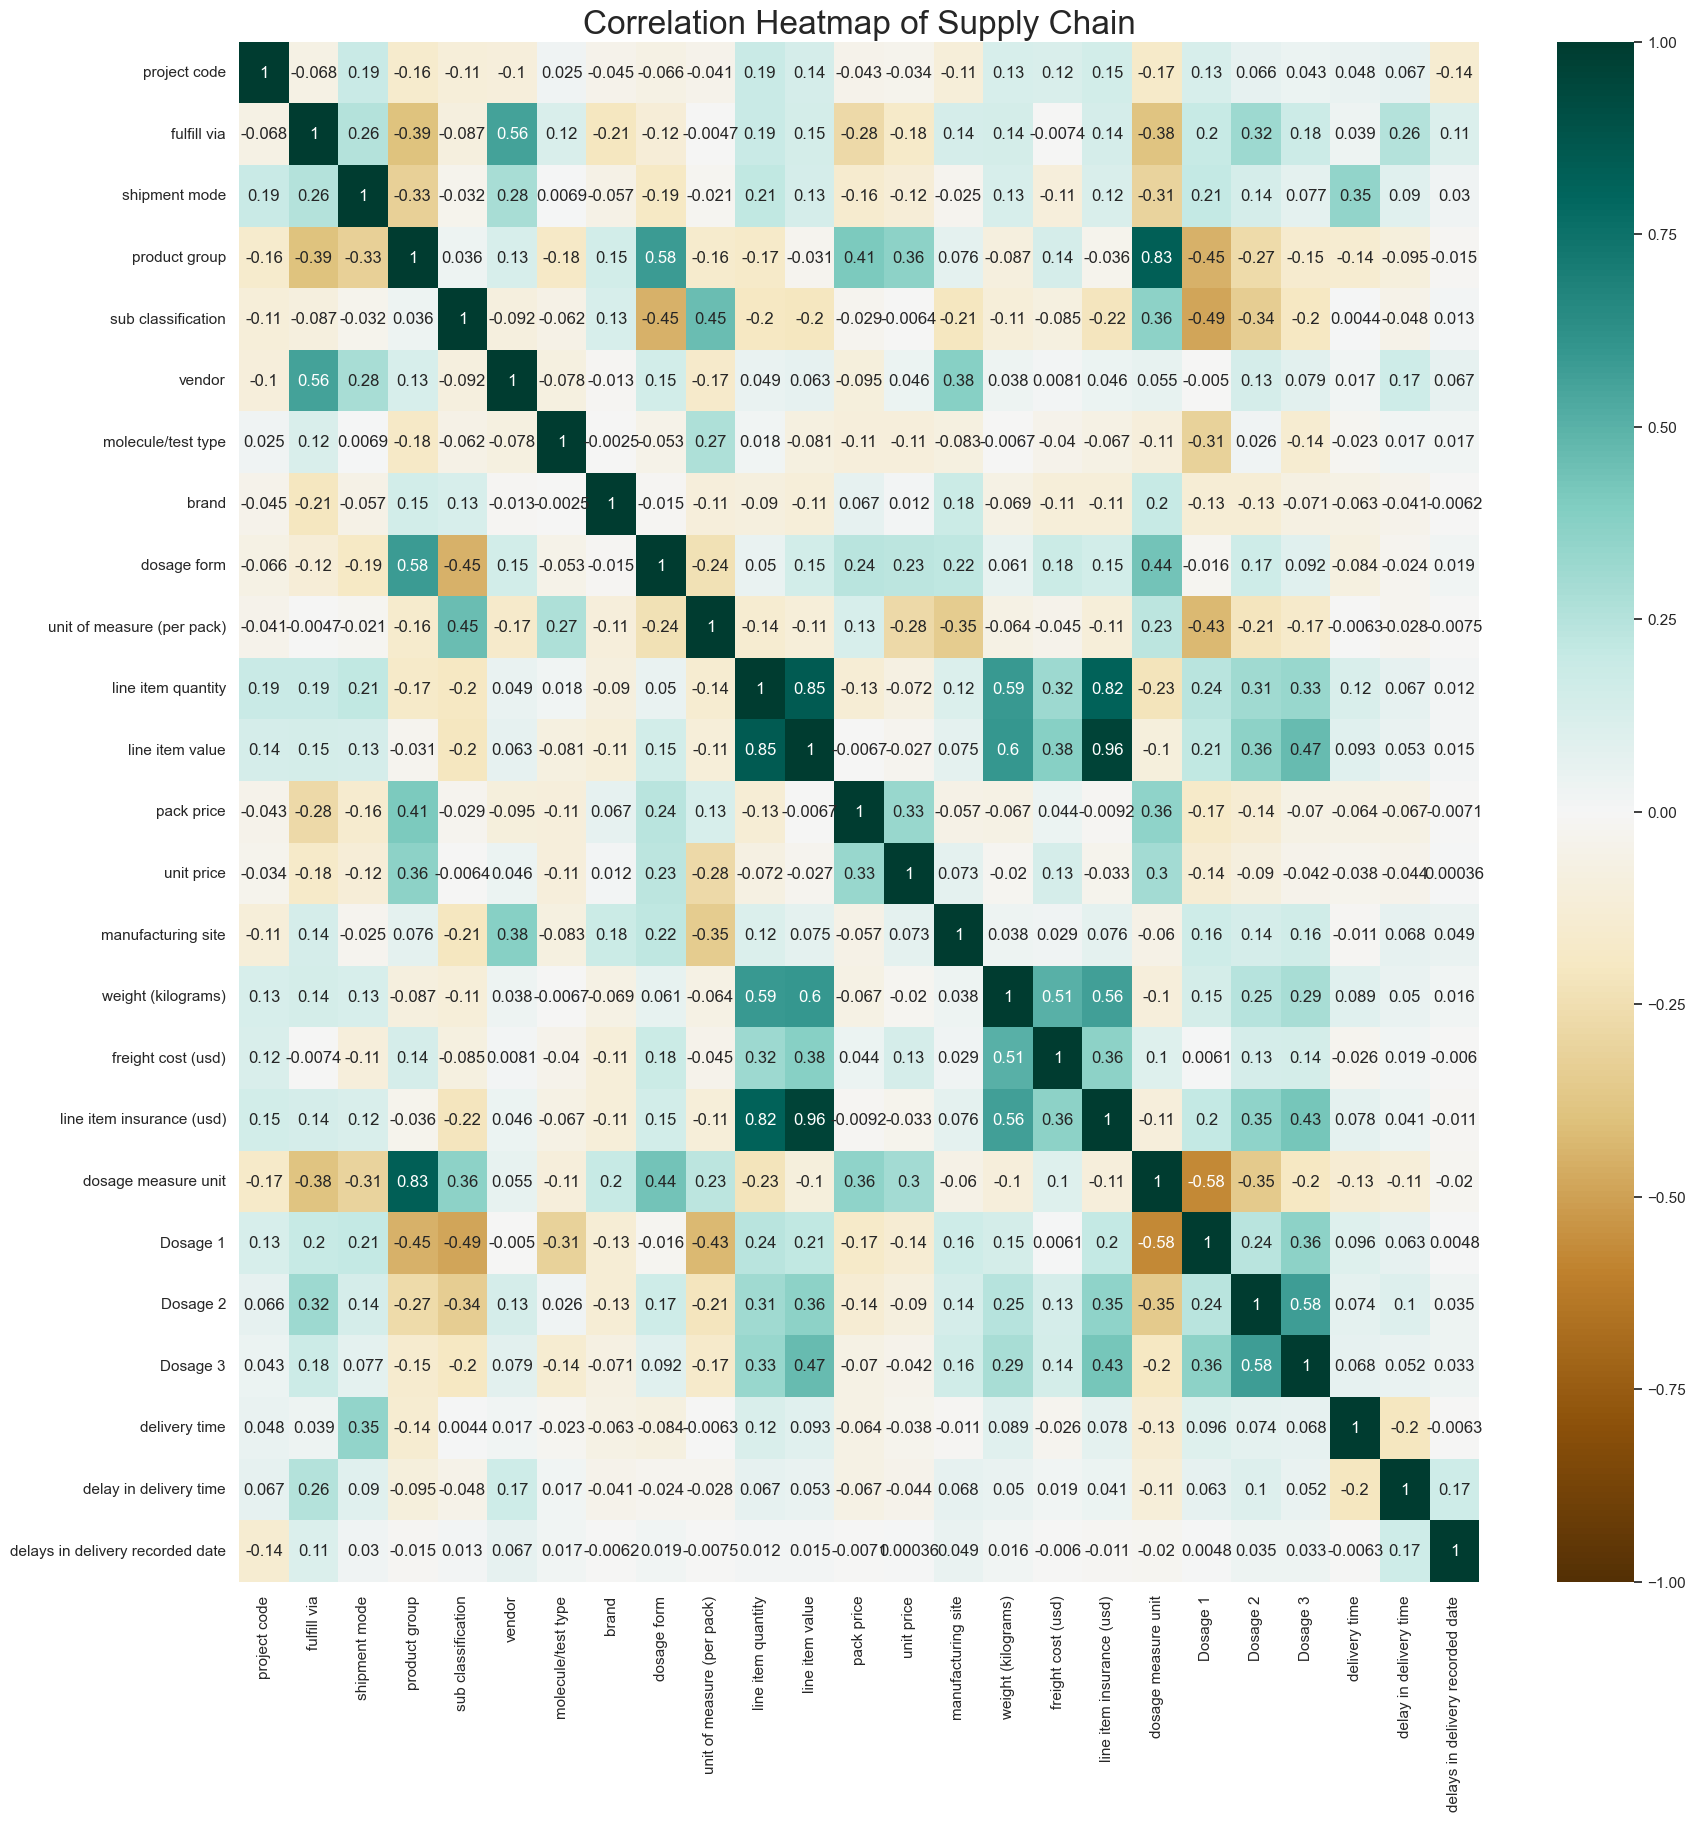

In [147]:
plt.figure(figsize = (20, 20))
heatmap = sns.heatmap (supply.corr(),vmin = -1, vmax = 1, annot = True,  cmap = "BrBG")
heatmap.set_title("Correlation Heatmap of Supply Chain", fontsize=24)

## **g) New columns to drop due to low correlation**

In [148]:
columns_todrop = ["delivery time", "delay in delivery time", "delays in delivery recorded date", "molecule/test type", "brand", "vendor"]
supply.drop(columns=columns_todrop, inplace=True)

Text(0.5, 1.0, 'Correlation Heatmap of Supply Chain')

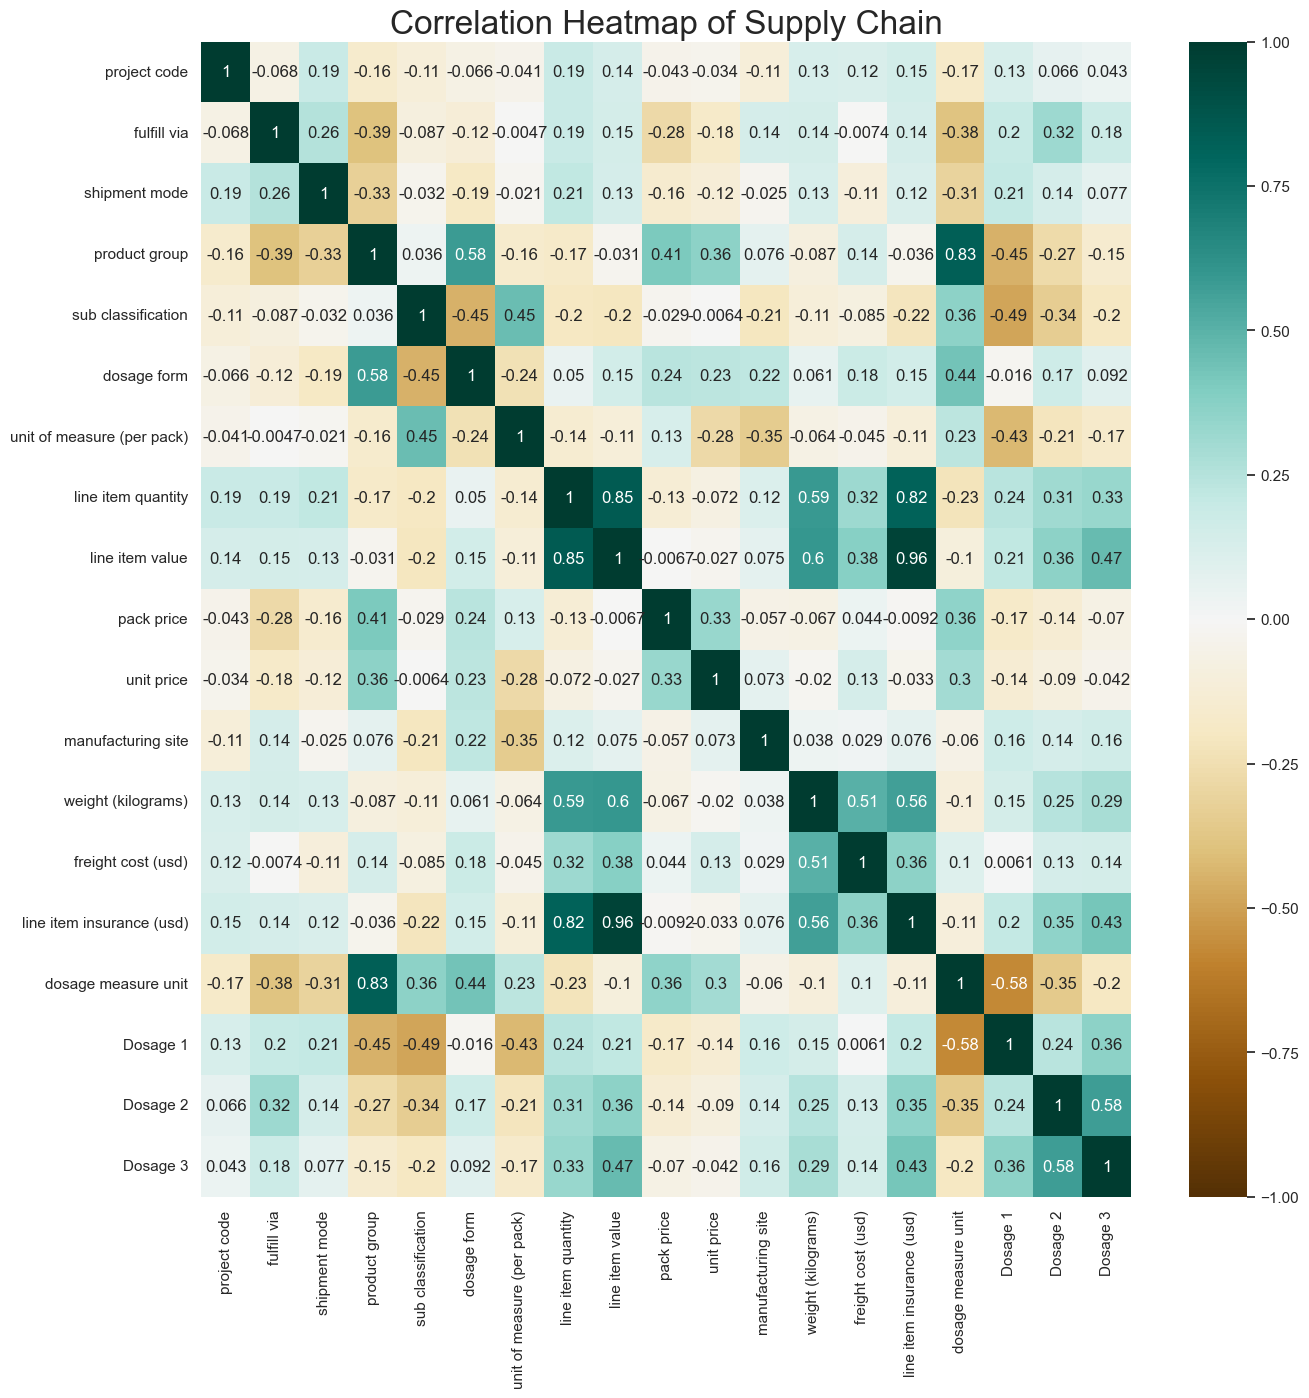

In [149]:
plt.figure(figsize = (15, 15))
heatmap = sns.heatmap (supply.corr(),vmin = -1, vmax = 1, annot = True,  cmap = "BrBG")
heatmap.set_title("Correlation Heatmap of Supply Chain", fontsize=24)

In [150]:
supply.head()

,project code,fulfill via,shipment mode,product group,sub classification,dosage form,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,weight (kilograms),freight cost (usd),line item insurance (usd),dosage measure unit,Dosage 1,Dosage 2,Dosage 3
18,45,0,0,2,1,10,12,525,3465.00,6.60,0.11,18,34.00,807.47,4.86,1,300.00,0.00,0.00
2682,17,0,0,3,2,15,15,1,80.00,80.00,0.80,37,1028.00,10083.69,0.17,5,0.00,0.00,0.00
2683,45,0,0,2,1,11,12,11092,74871.00,6.75,0.11,51,957.00,1869.41,92.62,1,150.00,300.00,0.00
2684,48,0,0,3,2,15,15,6280,502400.00,80.00,0.80,6,2548.00,28709.52,516.47,5,0.00,0.00,0.00
2685,43,0,0,2,5,2,12,298,685.40,2.30,0.04,18,21.00,304.62,0.96,1,30.00,50.00,6.00


In [151]:
supply.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7643 entries, 18 to 10323
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   project code                7643 non-null   int32  
 1   fulfill via                 7643 non-null   int32  
 2   shipment mode               7643 non-null   int32  
 3   product group               7643 non-null   int32  
 4   sub classification          7643 non-null   int32  
 5   dosage form                 7643 non-null   int32  
 6   unit of measure (per pack)  7643 non-null   int64  
 7   line item quantity          7643 non-null   int64  
 8   line item value             7643 non-null   float64
 9   pack price                  7643 non-null   float64
 10  unit price                  7643 non-null   float64
 11  manufacturing site          7643 non-null   int32  
 12  weight (kilograms)          7643 non-null   float64
 13  freight cost (usd)          764

# **1.4 Modelling**

## **a) Split into Train and Test data sets**

In [152]:
columns_to_drop = ["line item insurance (usd)"]

Y_train = supply["line item insurance (usd)"]

X_train = supply.drop(columns_to_drop, axis=1)

X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

# All sets contain the same amount of values to avoid error in processing time
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape)

(6114, 18) (6114,) (1529, 18) (1529,)


## **b) Random Forest Regressor**

In [153]:
rforest = RandomForestRegressor()
rforest = rforest.fit(X_train, Y_train)

# Predictions for Random Forest Regressor
Y_predrf = rforest.predict(X_val)

## **c) Gradient Boosting Machines**

In [154]:
gradientboost = GradientBoostingRegressor(loss="squared_error", n_estimators=100, learning_rate=0.1, max_depth=5)
gradientboost = gradientboost.fit(X_train, Y_train)

# Predictions for Gradient Boosting Machines
Y_predxg = gradientboost.predict(X_val)

## **d) Predictions of 10 first values**

In [166]:
# Actual Values
tenpred = list(Y_val[0:8])
print(tenpred)

# Random Forest
print(f"First 10 Random Forest Regressor: {Y_predrf[:8].round(2)}")

# Gradient Boosting Machines
print(f"First 10 Gradient Boosting Machines: {Y_predxg[:8].round(2)}")

[316.18, 1153.68, 1188.78, 57.6, 69.29, 10.21, 3.59, 1.45]
First 10 Random Forest Regressor: [ 350.27 1104.63 1140.1    56.78   70.83   10.03    3.47    1.43]
First 10 Gradient Boosting Machines: [ 363.89 1140.25 1128.48   57.5    67.22    4.82    4.03    4.51]


# **1.5 Evaluation**

## **a) Error Metrics**

In [156]:
# Random Forest
mae_rn = mean_absolute_error(Y_val, Y_predrf)
mse_rn = mean_squared_error(Y_val, Y_predrf)
r2_rn = r2_score(Y_val, Y_predrf)
rmse_rn = np.sqrt(mse_rn)
rss_rn = np.sum((Y_val - Y_predrf) ** 2)

# Gradient Boost 
mae_xg = mean_absolute_error(Y_val, Y_predxg)
mse_xg = mean_squared_error(Y_val, Y_predxg)
r2_xg = r2_score(Y_val, Y_predxg)
rmse_xg = np.sqrt(mse_xg)
rss_xg = np.sum((Y_val - Y_predxg) ** 2)

pd.set_option("display.float_format", "{:.2f}".format)

metrics = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", 
               "Root Mean Squared Error (RMSE)", "Residual Sum of Squares (RSS)", "R² Score"],
    "Random Forest": [mae_rn, mse_rn, rmse_rn, rss_rn, r2_rn * 100],
    "Gradient Boost": [mae_xg, mse_xg, rmse_xg, rss_xg, r2_xg * 100]
})

metrics["Random Forest compared to Gradien Boost"] = metrics["Random Forest"] - metrics["Gradient Boost"]

metrics

,Metric,Random Forest,Gradient Boost,Random Forest compared to Gradien Boost
0,Mean Absolute Error (MAE),33.36,29.32,4.03
1,Mean Squared Error (MSE),7038.65,5289.38,1749.26
2,Root Mean Squared Error (RMSE),83.90,72.73,11.17
3,Residual Sum of Squares (RSS),10762094.39,8087468.65,2674625.74
4,R² Score,97.39,98.04,-0.65


### **b) Actual vs Predicted Values**

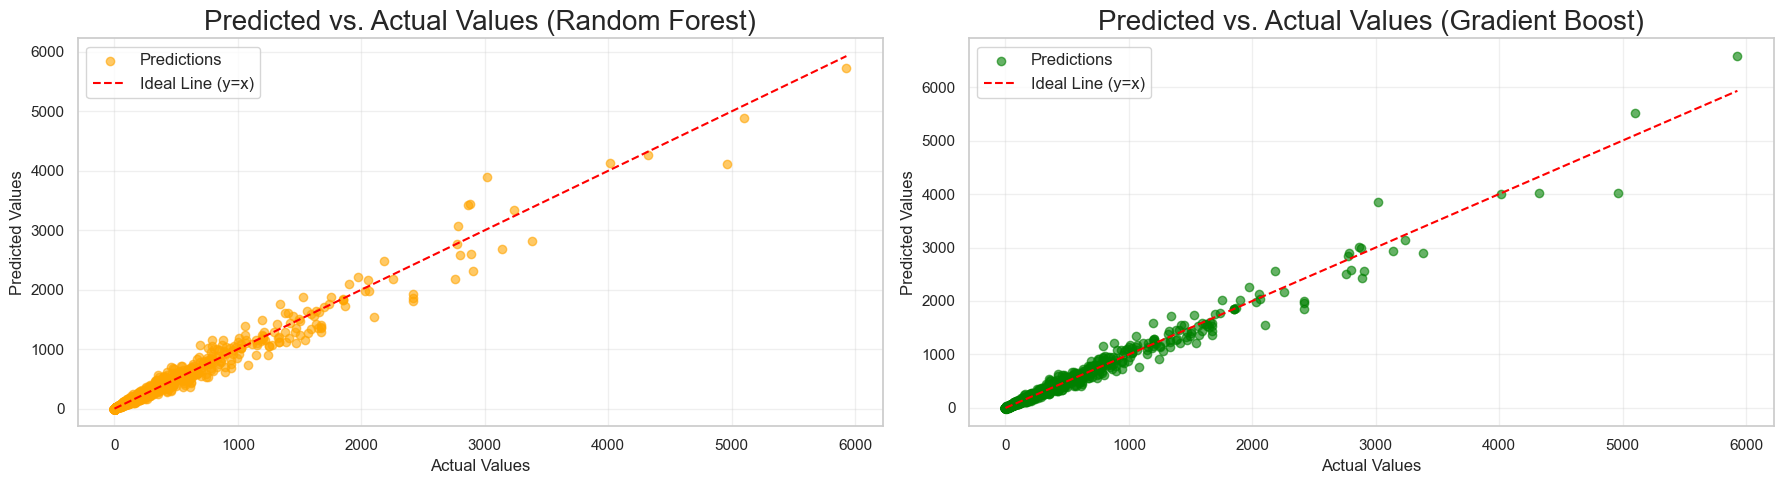

In [157]:
plt.figure(figsize=(18, 5))

# Random Forest
plt.subplot(1, 2, 1)
plt.scatter(Y_val, Y_predrf, alpha=0.6, color="orange", label="Predictions")
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], color="red", linestyle="--", label="Ideal Line (y=x)")
plt.title("Predicted vs. Actual Values (Random Forest)", fontsize=20)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Gradient Boost
plt.subplot(1, 2, 2)
plt.scatter(Y_val, Y_predxg, alpha=0.6, color="green", label="Predictions")
plt.plot([Y_val.min(), Y_val.max()], [Y_val.min(), Y_val.max()], color="red", linestyle="--", label="Ideal Line (y=x)")
plt.title("Predicted vs. Actual Values (Gradient Boost)", fontsize=20)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **c) Distribution of Residuals**

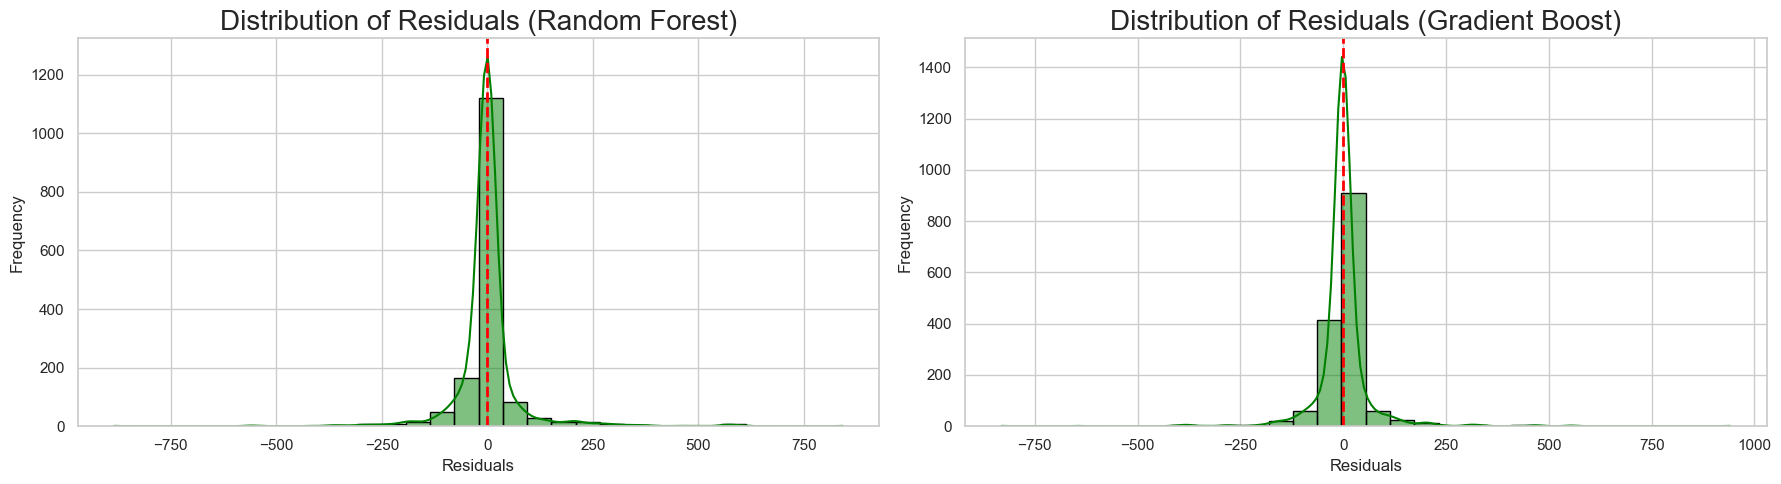

In [158]:
residualsrf = Y_val - Y_predrf
residualsxg = Y_val - Y_predxg
plt.figure(figsize=(18, 5))

# Random Forest
plt.subplot(1, 2, 1)
sns.histplot(residualsrf, kde=True, color="green", bins=30, edgecolor="black")
plt.axvline(x=0, color="red", linewidth=2, linestyle="--")
plt.title("Distribution of Residuals (Random Forest)", fontsize=20)
plt.xlabel("Residuals", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Gradient Boost
plt.subplot(1, 2, 2)
sns.histplot(residualsxg, kde=True, color="green", bins=30, edgecolor="black")
plt.axvline(x=0, color="red", linewidth=2, linestyle="--")
plt.title("Distribution of Residuals (Gradient Boost)", fontsize=20)
plt.xlabel("Residuals", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

### **c) Residuals vs Actual Values**

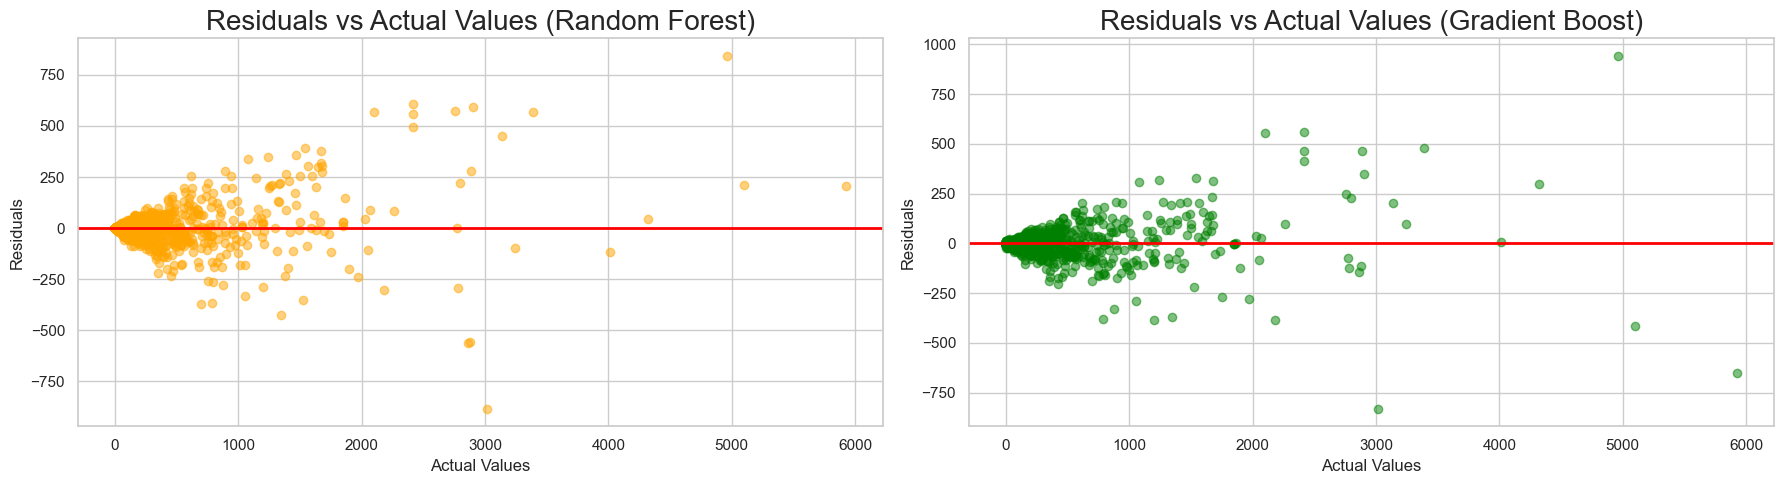

In [159]:
plt.figure(figsize=(18, 5))

# Random Forest
plt.subplot(1, 2, 1)
plt.scatter(Y_val, residualsrf, color='orange', alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual Values (Random Forest)", fontsize=20)

# Gradient Boost
plt.subplot(1, 2, 2)
plt.scatter(Y_val, residualsxg, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual Values (Gradient Boost)", fontsize=20)

plt.tight_layout()
plt.show()

### **d) Cross Validation**

In [167]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cvs = cross_val_score(rforest, X_train, Y_train, cv=cv, scoring="neg_mean_squared_error")
rfrmses = np.sqrt(-rf_cvs)
meanrf_rmse = np.mean(rfrmses)
print("Mean RMSE for Random Forest Regressor:", meanrf_rmse.round(2))


xg_cvs = cross_val_score(gradientboost, X_train, Y_train, cv=cv, scoring="neg_mean_squared_error")
xgrmses = np.sqrt(-xg_cvs)
meanxg_rmse = np.mean(xgrmses)
print("Mean RMSE for Gradient Boosting Regressor:", meanxg_rmse.round(2))

Mean RMSE for Random Forest Regressor: 108.28
Mean RMSE for Gradient Boosting Regressor: 88.15
